## Tier 4 — LLM Few-Shot Classification (`qwen3:8b` via Ollama)

Zero training involved, so this isn't evaluated the same way as the TF-IDF/embedding
tiers: no train/test *fitting* happens, no 5-fold CV cell at the end (there's nothing
to re-fit per fold). What still matters for a fair comparison is using the **same
test split** as the other two notebooks, so all three macro-F1 numbers are computed
on the same rows.

**This is the Colab (T4 GPU) variant.** Run the *Colab GPU setup* cells right below
once per session -- they install Ollama, start its server on the GPU, and pull
`qwen3:8b` (~5.2GB, fits easily in the T4's 16GB VRAM). The rest of the notebook is
identical to the local version: same few-shot prompting (`FEWSHOT_PER_CLASS = 2`,
unchanged), same 511-row test split, same caching to `llm_predictions_cache.json`.


### Colab GPU setup (run once per session)

Before running these three cells: **Runtime -> Change runtime type -> T4 GPU**.

1. Upload `deshimula_all_reviews_new.csv` into this Colab session (Files pane on the
   left, or `from google.colab import files; files.upload()`) -- put it in the same
   folder as this notebook (`/content/` by default). The data-loading cell below
   looks there automatically.
2. If you also have a partial `llm_predictions_cache.json` from a local run, upload
   it the same way to resume instead of starting from 0 -- otherwise the run just
   starts fresh (fast enough on the T4 that it barely matters).
3. Run the 3 setup cells below once, then run the rest of the notebook top to bottom.


In [8]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv


name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB


In [7]:
import sys

# Install zstd, which ollama needs for extraction.
!sudo apt-get update && sudo apt-get install -y zstd

# Install the Ollama server (auto-detects and uses the T4 GPU) and its python client.
!curl -fsSL https://ollama.com/install.sh | sh
!pip install -q ollama

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,920 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,187 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restr

In [9]:
import subprocess, time

# Start the Ollama server in the background and give it a moment to come up.
ollama_proc = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
time.sleep(5)

!ollama pull qwen3:8b
!ollama list



NAME        ID              SIZE      MODIFIED               
qwen3:8b    500a1f067a9f    5.2 GB    Less than a second ago    


In [10]:
import os
import re
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ollama

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)

In [11]:
import os

# Local layout has the CSV one directory up; a Colab upload usually lands it
# right next to the notebook -- try both so this cell works in either place.
CSV_CANDIDATES = ['deshimula_all_reviews_new.csv', '../deshimula_all_reviews_new.csv']
CSV_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), CSV_CANDIDATES[0])

df = pd.read_csv(CSV_PATH)
NUM_SAMPLES = 2552
sentiment_df = df[['content', 'vibe']][:NUM_SAMPLES]
sentiment_df.shape


(2552, 2)

In [12]:
X = sentiment_df['content']
y = sentiment_df['vibe']

# Same split as the TF-IDF and embedding notebooks (random_state=42, same stratify)
# so macro-F1 is directly comparable across all tiers.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
print(y_test.value_counts())

Training samples: 2041, Testing samples: 511
vibe
Negative    396
Positive     58
Mixed        57
Name: count, dtype: int64


In [13]:
MODEL = "qwen3:8b"
LABELS = sorted(y.unique().tolist())

# A handful of real few-shot examples pulled from the TRAINING set only
# (never from X_test) -- truncated so the prompt stays short on CPU inference.
FEWSHOT_PER_CLASS = 2
MAX_CHARS = 400

fewshot_df = (
    pd.DataFrame({'content': X_train, 'vibe': y_train})
    .groupby('vibe', group_keys=False)
    .sample(n=FEWSHOT_PER_CLASS, random_state=42)
)
fewshot_examples = [
    (row.content[:MAX_CHARS], row.vibe) for row in fewshot_df.itertuples()
]
len(fewshot_examples)

6

In [14]:
SYSTEM_PROMPT = (
    "/no_think\n"  # disable Qwen3's chain-of-thought (the `think=False` kwarg
                   # only exists in ollama>=0.5; this tag works on every version)
    "You classify the overall sentiment of employee reviews of Bangladeshi software "
    "companies. Reviews may be written in Bangla, English, Banglish (romanized Bangla), "
    "or a mix of all three within the same review.\n\n"
    f"Classify each review as exactly one of: {', '.join(LABELS)}.\n"
    "- Positive: predominantly favorable, even if minor complaints are mentioned.\n"
    "- Negative: predominantly unfavorable, even if minor positives are mentioned.\n"
    "- Mixed: genuinely balanced pros and cons, with no clear lean either way.\n\n"
    'Respond with only the label as JSON, e.g. {"label": "Positive"}.'
)

RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {"label": {"type": "string", "enum": LABELS}},
    "required": ["label"],
}

def build_messages(review_text):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for example_text, example_label in fewshot_examples:
        messages.append({"role": "user", "content": example_text})
        messages.append({"role": "assistant", "content": json.dumps({"label": example_label})})
    messages.append({"role": "user", "content": review_text[:1500]})
    return messages

In [15]:
import inspect as _inspect

# ollama < 0.5 (this box has 0.4.8) has no `think` kwarg -- passing it made
# EVERY ollama.chat() call raise TypeError, which the bare `except` swallowed,
# so all 511 rows silently fell back to LABELS[0] ("Mixed"). Only pass `think`
# when the installed client actually supports it; Qwen3 reasoning is disabled
# via the `/no_think` tag in SYSTEM_PROMPT regardless.
_SUPPORTS_THINK = "think" in _inspect.signature(ollama.chat).parameters

LABEL_RE = re.compile("|".join(re.escape(l) for l in LABELS), re.IGNORECASE)

def classify_review(review_text, max_retries=2):
    messages = build_messages(review_text)
    kwargs = dict(
        model=MODEL,
        messages=messages,
        format=RESPONSE_SCHEMA,
        options={"temperature": 0},
    )
    if _SUPPORTS_THINK:
        kwargs["think"] = False

    content = None
    for attempt in range(max_retries + 1):
        try:
            response = ollama.chat(**kwargs)
            content = response.message.content
            label = json.loads(content)["label"]
            if label in LABELS:
                return label, False
        except Exception as e:
            classify_review.last_error = e   # surfaced by the run cell if all rows fail

    # Fallback: regex-scan the last raw response for a label word; else mark as failed.
    match = LABEL_RE.search(content) if content else None
    if match:
        canon = next(l for l in LABELS if l.lower() == match.group(0).lower())
        return canon, True
    return LABELS[0], True

classify_review.last_error = None

In [16]:
CACHE_PATH = "llm_predictions_cache.json"

def load_cache():
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f)

cache = load_cache()
print(f"{len(cache)} predictions already cached")

0 predictions already cached


In [17]:
n_failures = 0
t0 = time.time()

try:
    for i, (idx, text) in enumerate(X_test.items()):
        key = str(idx)
        if key in cache:
            continue

        label, failed = classify_review(text)
        cache[key] = label
        n_failures += failed

        if (i + 1) % 25 == 0:
            save_cache(cache)
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            eta = (len(X_test) - (i + 1)) / rate
            print(f"{i + 1}/{len(X_test)}  ({rate:.2f} rows/s, ETA {eta / 60:.1f} min, {n_failures} fallback labels)")
finally:
    save_cache(cache)

print(f"Done. {n_failures} rows needed the regex fallback.")
if n_failures > 0.5 * len(X_test) and classify_review.last_error is not None:
    print(f"\n!! {n_failures}/{len(X_test)} rows failed -- last ollama error was:")
    print(f"   {type(classify_review.last_error).__name__}: {classify_review.last_error}")
    print("   (is `ollama serve` running? is qwen3:8b pulled?)")

25/511  (0.17 rows/s, ETA 48.0 min, 0 fallback labels)
50/511  (0.29 rows/s, ETA 26.3 min, 0 fallback labels)
75/511  (0.38 rows/s, ETA 19.3 min, 0 fallback labels)
100/511  (0.43 rows/s, ETA 15.9 min, 0 fallback labels)
125/511  (0.48 rows/s, ETA 13.5 min, 0 fallback labels)
150/511  (0.51 rows/s, ETA 11.8 min, 0 fallback labels)
175/511  (0.55 rows/s, ETA 10.2 min, 0 fallback labels)
200/511  (0.59 rows/s, ETA 8.8 min, 0 fallback labels)
225/511  (0.62 rows/s, ETA 7.7 min, 0 fallback labels)
250/511  (0.65 rows/s, ETA 6.7 min, 0 fallback labels)
275/511  (0.67 rows/s, ETA 5.9 min, 0 fallback labels)
300/511  (0.69 rows/s, ETA 5.1 min, 0 fallback labels)
325/511  (0.71 rows/s, ETA 4.4 min, 0 fallback labels)
350/511  (0.71 rows/s, ETA 3.8 min, 0 fallback labels)
375/511  (0.72 rows/s, ETA 3.1 min, 0 fallback labels)
400/511  (0.74 rows/s, ETA 2.5 min, 0 fallback labels)
425/511  (0.75 rows/s, ETA 1.9 min, 0 fallback labels)
450/511  (0.75 rows/s, ETA 1.4 min, 0 fallback labels)
475/51

In [18]:
llm_preds = np.array([cache[str(idx)] for idx in X_test.index])

def evaluate(preds, name):
    accuracy = np.mean(preds == y_test.values)
    macro_f1 = f1_score(y_test, preds, average='macro')
    print(f"{name} - Accuracy: {accuracy:.4f}, Macro F1 Score: {macro_f1:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    return preds

llm_preds = evaluate(llm_preds, f"{MODEL} (few-shot, thinking off)")

qwen3:8b (few-shot, thinking off) - Accuracy: 0.8493, Macro F1 Score: 0.6605
              precision    recall  f1-score   support

       Mixed       0.36      0.35      0.36        57
    Negative       0.92      0.96      0.94       396
    Positive       0.80      0.60      0.69        58

    accuracy                           0.85       511
   macro avg       0.69      0.64      0.66       511
weighted avg       0.84      0.85      0.84       511



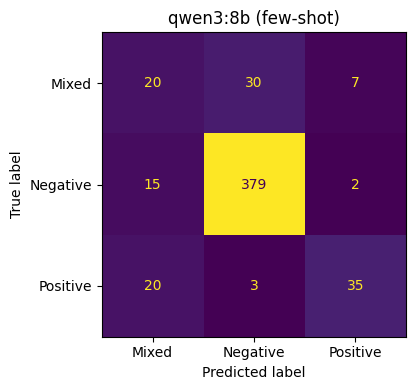

In [19]:
cm = confusion_matrix(y_test, llm_preds, labels=sorted(y.unique()))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique())).plot(ax=ax, colorbar=False)
ax.set_title(f"{MODEL} (few-shot)")
plt.tight_layout()
plt.show()

**Next:** line this macro-F1 up against the TF-IDF and `e5-large` embedding
notebooks — same 510-row test set, so the numbers are directly comparable. If you
also want the label-audit / pseudo-labeling use cases from the Tier 4 plan, that's a
separate run over the *full* `sentiment_df` (not just `X_test`) — worth keeping in a
different notebook so it doesn't get mixed up with this comparison.